# Système de Recommandation Netflix - Exploration & Visualisation

Système de recommandation basé sur la similarité de contenu (Content-Based Filtering) utilisant le NLP.

**Techniques utilisées :**
- TF-IDF Vectorization
- Cosine Similarity
- Gestion des fautes de frappe (difflib)

**Importation des bibliothèques et fonctions**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from recommender import load_data, explore_data, clean_data, create_features, vectorize, get_recommendations, fit
from recommender import df, cosine_sim, indices

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

**Chargement et exploration**

In [12]:
# Charger les données
load_data('netflix_titles.csv')

# Explorer
explore_data()

Dataset chargé : 8807 lignes, 12 colonnes
=== Exploration du dataset ===
Nombre de titres : 8807
Nombre de colonnes : 12

Valeurs manquantes :
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Répartition Films/Séries :
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


**Afficher les premières lignes** 

In [13]:
from recommender import df
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Nettoyage et features**

In [14]:
# Nettoyer les données
clean_data()

# Créer les features
create_features()

# Vérifier le résultat
from recommender import df
df[['title', 'title_clean', 'features']].head()

Nettoyage terminé 
Features créées 
Exemple : dick johnson is dead documentaries as her father nears the end of his life filmmaker kirsten johnson...


,title,title_clean,features
0,Dick Johnson Is Dead,dick johnson is dead,dick johnson is dead documentaries as her fath...
1,Blood & Water,blood water,blood water international tv shows tv dramas ...
2,Ganglands,ganglands,ganglands crime tv shows international tv show...
3,Jailbirds New Orleans,jailbirds new orleans,jailbirds new orleans docuseries reality tv fe...
4,Kota Factory,kota factory,kota factory international tv shows romantic t...


**Vectorisation**

In [15]:
# Vectoriser
vectorize()

from recommender import tfidf, df
print(f"Nombre de films : {df.shape[0]}")
print(f"Nombre de mots uniques : {tfidf.fit_transform(df['features']).shape[1]}")

Matrice TF-IDF : (8807, 56046)
Vectorisation terminée
Nombre de films : 8807
Nombre de mots uniques : 56046


**Répartition Films/Séries**

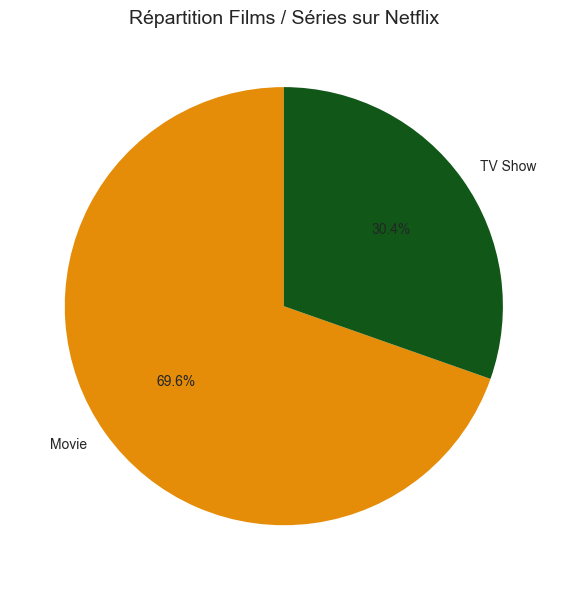

In [16]:
from recommender import df
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=["#E58D09", "#105718"],
    startangle=90
)
plt.title('Répartition Films / Séries sur Netflix', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

**Distribution des genres**

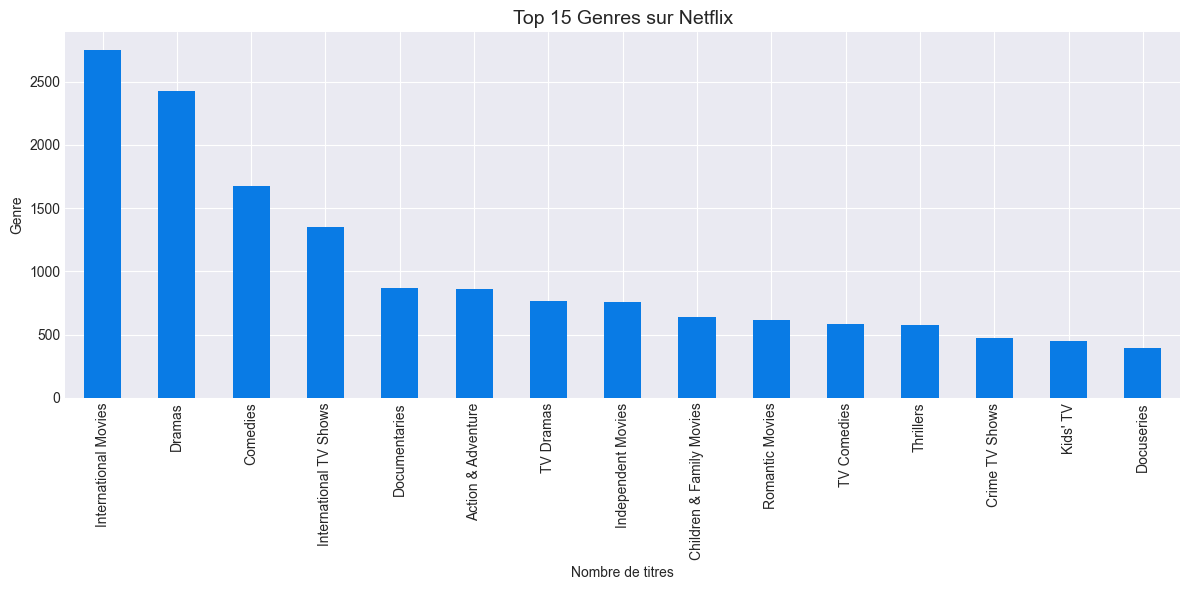

In [27]:
# Séparer les genres (un film peut avoir plusieurs genres)
genres = df['listed_in'].str.split(', ').explode()

plt.figure(figsize=(12, 6))
genres.value_counts().head(15).plot(
    kind='bar',
    color="#097BE5"
)
plt.title('Top 15 Genres sur Netflix', fontsize=14)
plt.xlabel('Nombre de titres')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Matrice de similarité cosinus**

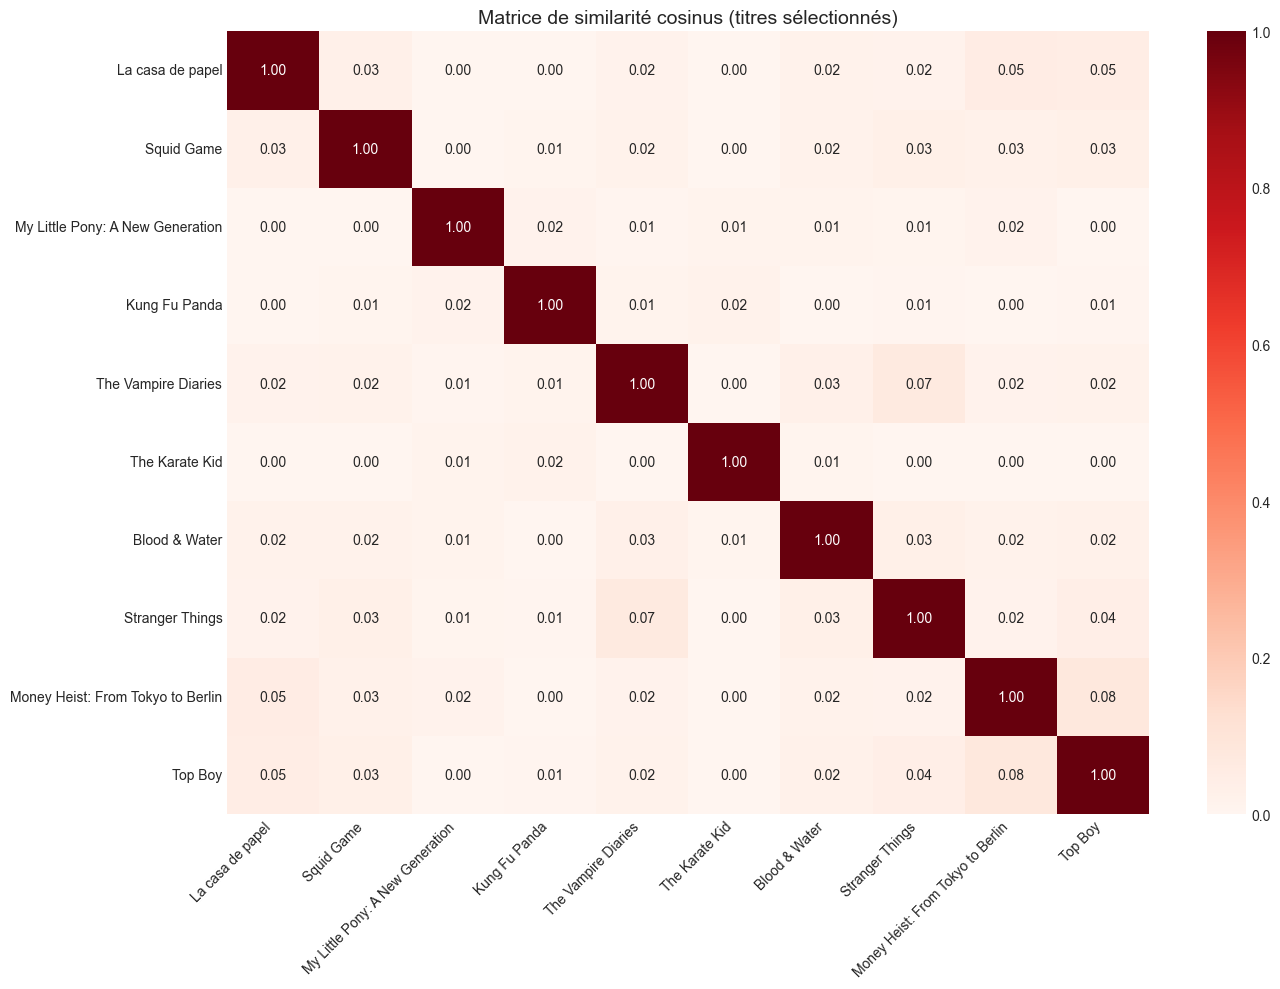

In [ ]:
from recommender import df, cosine_sim, indices
import numpy as np
import re
# Titres demandés (orthographe telle qu'elle apparaît dans le CSV)
titles = [
    'La casa de papel',
    'Squid Game',
    'My Little Pony: A New Generation',
    'Kung Fu Panda',
    'The Vampire Diaries',
    'The Karate Kid',
    'Blood & Water',
    'Stranger Things',
    'Money Heist: From Tokyo to Berlin',
    'Top Boy'
]
# Résoudre les indices dans le DataFrame de façon robuste
idx_list = []
for t in titles:
    # Cherche correspondance exacte sur la colonne title
    matches = df.index[df['title'] == t].tolist()
    if matches:
        idx_list.append(matches[0])
        continue
    # Sinon essayer via title_clean (nettoyage utilisé par le pipeline)
    t_clean = re.sub(r'[^a-z0-9\s]', '', t.lower())
    if t_clean in indices:
        idx_list.append(int(indices[t_clean]))
    else:
        print(f'"{t}" non trouvé dans le dataset')

# Construire et afficher la heatmap
plt.figure(figsize=(14, 10))
sim_matrix = cosine_sim[np.ix_(idx_list, idx_list)]
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    xticklabels=[df.loc[i, 'title'] for i in idx_list],
    yticklabels=[df.loc[i, 'title'] for i in idx_list]
)
plt.title('Matrice de similarité cosinus (titres sélectionnés)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Test et Recommandation**

In [20]:
# Test normal
print("=== Test normal ===")
data = get_recommendations("Stranger Things", top_n=5)
if 'error' in data:
    print(data['error'])
else:
    print(data['results'][['title', 'type', 'listed_in']])


=== Test normal ===
                    title     type  \
0  Beyond Stranger Things  TV Show   
1        Prank Encounters  TV Show   
2                     Eli    Movie   
3               Homefront    Movie   
4              Safe Haven    Movie   

                                           listed_in  
0  Stand-Up Comedy & Talk Shows, TV Mysteries, TV...  
1                 Reality TV, TV Comedies, TV Horror  
2                                      Horror Movies  
3                                 Action & Adventure  
4                            Dramas, Romantic Movies  


In [21]:
# Test avec faute de frappe
print("\n=== Test avec faute de frappe ===")
data = get_recommendations("Starnger Thigns", top_n=5)
if 'error' in data:
    print(data['error'])
else:
    if data['correction']:
        print(data['correction'])
    print(data['results'][['title', 'type', 'listed_in']])



=== Test avec faute de frappe ===
'Starnger Thigns' non trouvé. Résultats pour : 'Stranger Things'
                    title     type  \
0  Beyond Stranger Things  TV Show   
1        Prank Encounters  TV Show   
2                     Eli    Movie   
3               Homefront    Movie   
4              Safe Haven    Movie   

                                           listed_in  
0  Stand-Up Comedy & Talk Shows, TV Mysteries, TV...  
1                 Reality TV, TV Comedies, TV Horror  
2                                      Horror Movies  
3                                 Action & Adventure  
4                            Dramas, Romantic Movies  


In [26]:
# Test avec filtre type
print("\n=== Test avec filtre Movie ===")
data = get_recommendations("Jackson", top_n=5, content_type="Movie")
if 'error' in data:
    print(data['error'])
else:
    print(data['results'][['title', 'type', 'listed_in']])


=== Test avec filtre Movie ===
                          title   type                               listed_in
0                Professor Mack  Movie               Comedies, Romantic Movies
1  Black & Privileged: Volume 1  Movie                                  Dramas
2           Walk Away from Love  Movie                 Dramas, Romantic Movies
3               Must Be... Love  Movie  Comedies, Dramas, International Movies
4          Everything About Her  Movie  Comedies, Dramas, International Movies
